<h1 style = "font-size:2.5rem;color:orange;">Data Exploration by Jaz :) </h1

In [5]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

#load the data (items.csv and train.csv)
items = pd.read_csv("../data/raw/items.csv", sep="|")
train = pd.read_csv("../data/raw/train.csv", sep="|")

#show row and column total count
print(f"Loaded dataset items: {items.shape[0]} rows, {items.shape[1]} columns")
print(f"Loaded dataset train: {train.shape[0]} rows, {train.shape[1]} columns")

Loaded dataset items: 22035 rows, 11 columns
Loaded dataset train: 2756003 rows, 11 columns


In [6]:
#show whole items dataset --> quick look for any abnormalities
items

,pid,manufacturer,group,content,unit,pharmForm,genericProduct,salesIndex,category,campaignIndex,rrp
0,1,1,2FOI,80,ST,TAB,0,40,NaN,NaN,10.89
1,2,1,2FOI,80,ST,Tab,0,40,NaN,NaN,10.89
2,3,1,2FOI,10,G,GLO,0,40,NaN,NaN,16.45
3,4,1,2FOI,80,ST,TAB,0,40,NaN,NaN,10.89
4,5,2,10OJ03JS,8,ST,PUL,0,40,1.0,NaN,22.53
...,...,...,...,...,...,...,...,...,...,...,...
22030,22031,844,21OIG,100,ST,Tab,0,53,NaN,NaN,13.42
22031,22032,387,22OI3,475,ML,NaN,0,53,8.0,NaN,5.45
22032,22033,19,22OI3,100,G,SAL,0,53,NaN,NaN,6.60
22033,22034,79,22OIO,1,ST,NaN,0,53,NaN,NaN,27.49


Documentation: column "content" is a bit special bcuz it has different formats. Some Examples are:
- 4X200 --> 800 eigentlich?
- 30X0.6 --> Kommastelle
- 90 --> "normal format"
Action needed in the Cleaning process!

In [8]:
#show whole train dataset (high-level check)
train

,lineID,day,pid,adFlag,availability,competitorPrice,click,basket,order,price,revenue
0,1,1,6570,0,2,14.60,1,0,0,16.89,0.00
1,2,1,14922,1,1,8.57,0,1,0,8.75,0.00
2,3,1,16382,0,1,14.77,0,1,0,16.06,0.00
3,4,1,1145,1,1,6.59,0,0,1,6.55,6.55
4,5,1,3394,0,1,4.39,0,0,1,4.14,4.14
...,...,...,...,...,...,...,...,...,...,...,...
2755998,2755999,92,15767,0,1,22.41,1,0,0,18.64,0.00
2755999,2756000,92,2087,0,1,36.87,1,0,0,43.18,0.00
2756000,2756001,92,2944,0,1,4.71,1,0,0,5.59,0.00
2756001,2756002,92,3853,1,1,6.59,0,1,0,6.33,0.00


In [15]:
#Check for missing values
train.info()
train.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2756003 entries, 0 to 2756002
Data columns (total 11 columns):
 #   Column           Dtype  
---  ------           -----  
 0   lineID           int64  
 1   day              int64  
 2   pid              int64  
 3   adFlag           int64  
 4   availability     int64  
 5   competitorPrice  float64
 6   click            int64  
 7   basket           int64  
 8   order            int64  
 9   price            float64
 10  revenue          float64
dtypes: float64(3), int64(8)
memory usage: 231.3 MB


lineID                  0
day                     0
pid                     0
adFlag                  0
availability            0
competitorPrice    100687
click                   0
basket                  0
order                   0
price                   0
revenue                 0
dtype: int64

Documentation: All columns are complete except for competitorPrice, which contains 100^687 missing values --> competitor price was not recorded or available??. CompetitorPrice needs action either with filling it out with the pharamxy own price (attribute price), or maybe use the refernece price (attribute rrp) as an estimation for the missing values in competitor price.

In [16]:
#Check for missing values
items.info()
items.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 22035 entries, 0 to 22034
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pid             22035 non-null  int64  
 1   manufacturer    22035 non-null  int64  
 2   group           22035 non-null  str    
 3   content         22035 non-null  str    
 4   unit            22035 non-null  str    
 5   pharmForm       19708 non-null  str    
 6   genericProduct  22035 non-null  int64  
 7   salesIndex      22035 non-null  int64  
 8   category        17408 non-null  float64
 9   campaignIndex   1338 non-null   str    
 10  rrp             22035 non-null  float64
dtypes: float64(2), int64(4), str(5)
memory usage: 1.8 MB


pid                   0
manufacturer          0
group                 0
content               0
unit                  0
pharmForm          2327
genericProduct        0
salesIndex            0
category           4627
campaignIndex     20697
rrp                   0
dtype: int64

Documentation: total products 22'035.
- pharmForm: 2'327 missing values --> products are missing the dosage form (tablets,film-coated tablets and so on).
- category: 4627 missing values --> products are not assigned to a main shop category (numbers)
- campaignIndex: 20697 missing values  --> maybe over 90% of this column is missing!!! (A,B,C labels)

<h6 style = "font-size:2.5rem;color:pink;">Visualization </h6

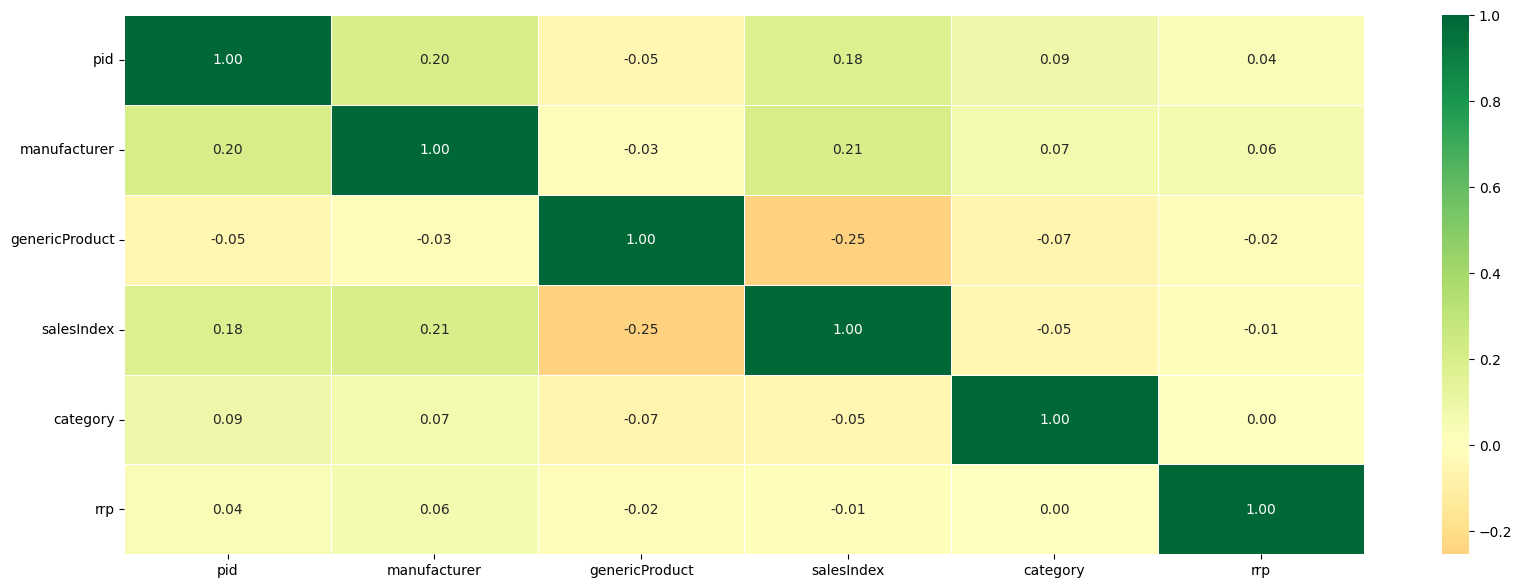

In [29]:
correlation_matrix = items.corr(numeric_only=True)

sns.heatmap(correlation_matrix, annot=True, cmap="RdYlGn", center=0, fmt='.2f', linewidths=.5) #
plt.rcParams["figure.figsize"] = (20, 7)
plt.show()

Documentation:
- +1.0 (blue): Perfect positive correlation. If one goes up, the other always goes up.
- 0.0 (green?): No linear relationship at all. These variables are independent.
- -1.0 (brownish??): Perfect negative correlation. If one goes up, the other goes down.

In [30]:
#Merging the datasets
#'left' to keep all 2.7 million rows of train and add item details to them
df_merged = pd.merge(train, items, on='pid', how='left')

print(f"Merge Complete! New shape: {df_merged.shape}")

Merge Complete! New shape: (2756003, 21)


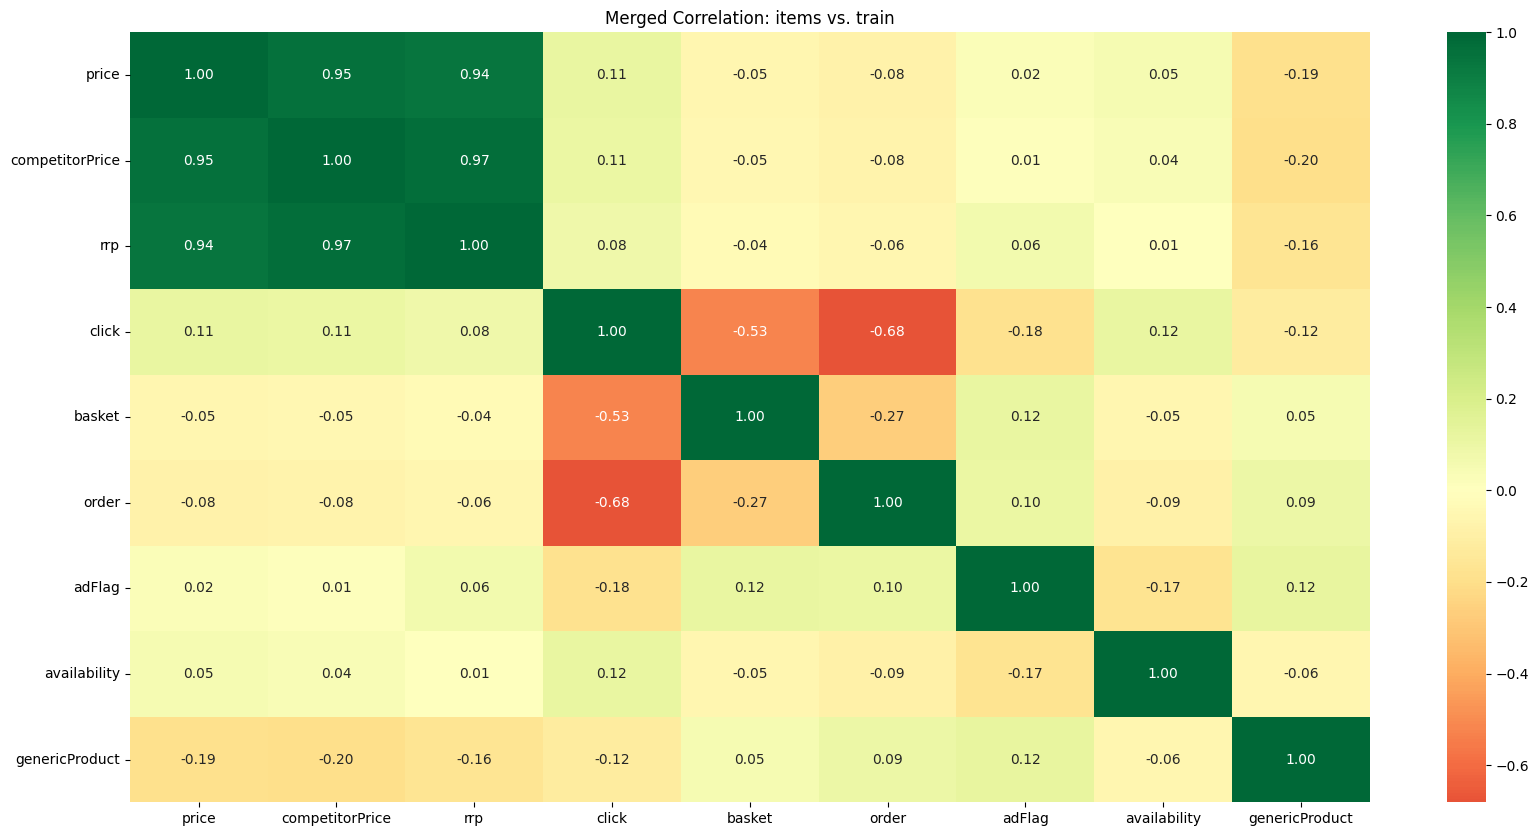

In [34]:
# Selecting columns relevant to pricing and user behavior
cols_to_analyze = [
    'price', 'competitorPrice', 'rrp',          # Pricing
    'click', 'basket', 'order',                 # Target Labels
    'adFlag', 'availability', 'genericProduct'  # Influencers
]

#Calculate correlation
merged_corr = df_merged[cols_to_analyze].corr(numeric_only=True)

#Plotting
plt.figure(figsize=(20, 10))
sns.heatmap(merged_corr, annot=True, cmap='RdYlGn', center=0, fmt=".2f")
plt.title('Merged Correlation: items vs. train')
plt.show()

Documentation: the color grading sucks

<Axes: >

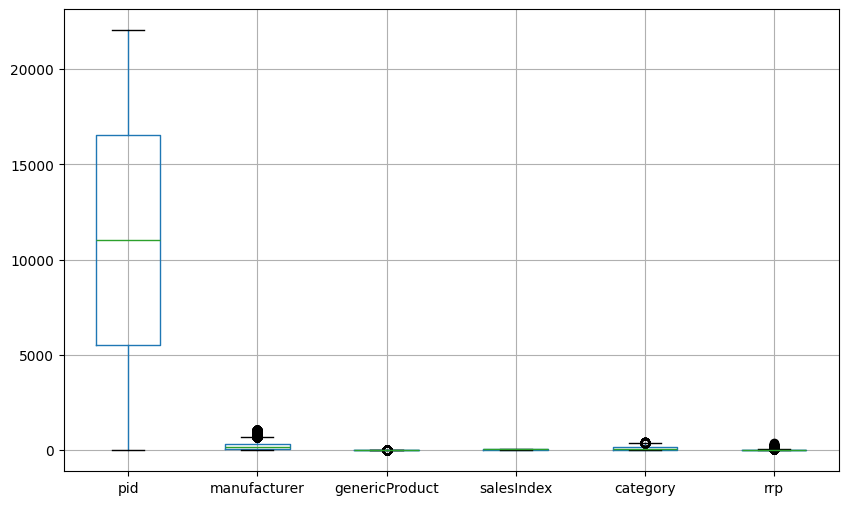

In [41]:
#Detection of Outliers items dataset
items.boxplot(figsize=(10, 6))

<Axes: >

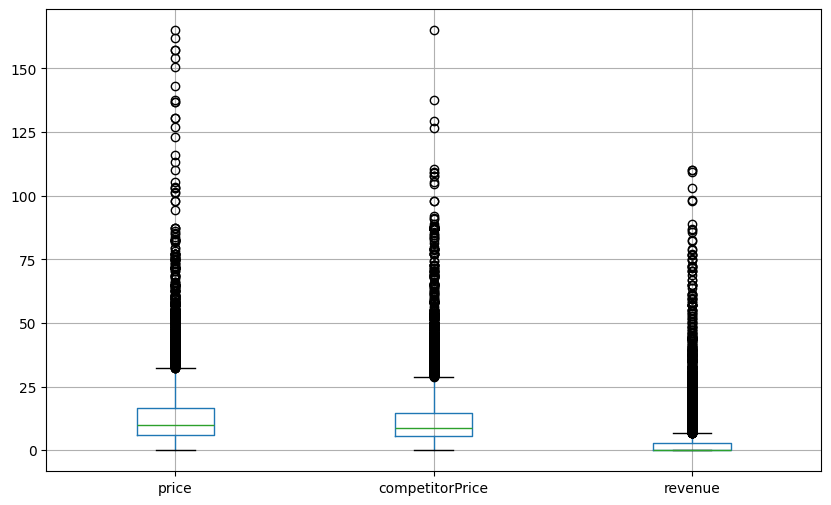

In [43]:
#Detection of Outliers train dataset (sample of 10^000) - money variables
train_sample = train.sample(n=10000, random_state=42)
train_sample[['price', 'competitorPrice', 'revenue']].boxplot(figsize=(10, 6))

<Axes: >

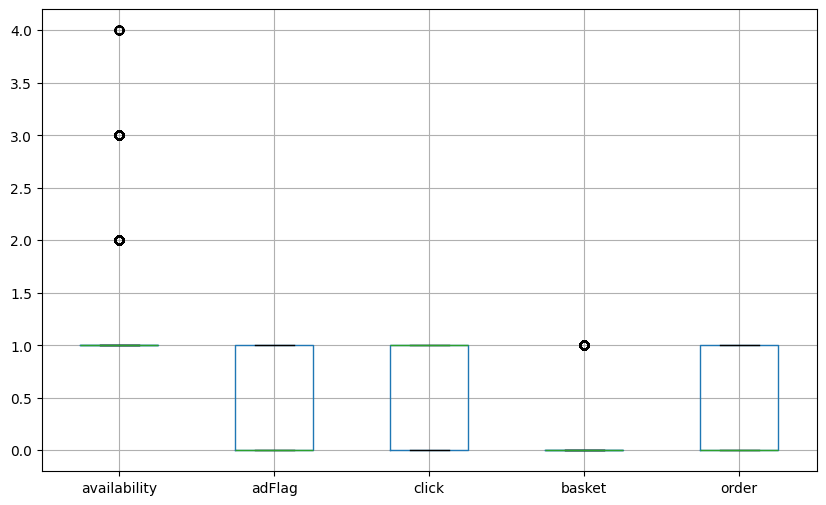

In [44]:
#Detection of Outliers train dataset (sample of 10^000) - binary
train_sample[['availability', 'adFlag', 'click', 'basket', 'order']].boxplot(figsize=(10, 6))